In [1]:
import json, time
from pathlib import Path
import cv2, numpy as np, matplotlib.pyplot as plt
from rtmlib import Wholebody, draw_skeleton

In [2]:
image_path = "/home/topiary-pc/Projects/MovesMethod/test.jpg"

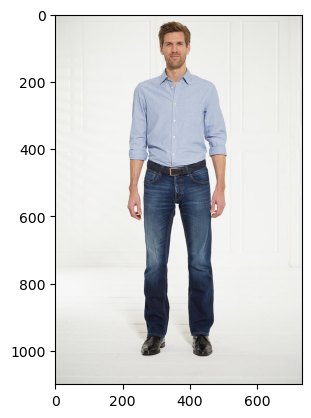

In [3]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [4]:
model = Wholebody(mode="lightweight", backend="onnxruntime", device="cpu")

load /home/topiary-pc/.cache/rtmlib/hub/checkpoints/yolox_tiny_8xb8-300e_humanart-6f3252f9.onnx with onnxruntime backend
load /home/topiary-pc/.cache/rtmlib/hub/checkpoints/rtmw-dw-l-m_simcc-cocktail14_270e-256x192_20231122.onnx with onnxruntime backend


2026-09-23 11:45:51.114876646 [W:onnxruntime:, graph.cc:4885 CleanUnusedInitializersAndNodeArgs] Removing initializer '1462'. It is not used by any node and should be removed from the model.
2026-09-23 11:45:51.114902201 [W:onnxruntime:, graph.cc:4885 CleanUnusedInitializersAndNodeArgs] Removing initializer '1470'. It is not used by any node and should be removed from the model.
2026-09-23 11:45:51.114912602 [W:onnxruntime:, graph.cc:4885 CleanUnusedInitializersAndNodeArgs] Removing initializer '1467'. It is not used by any node and should be removed from the model.


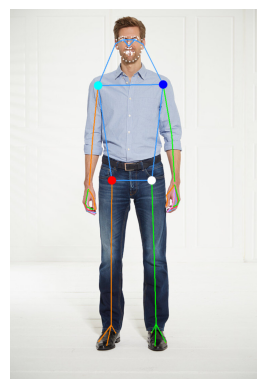

In [5]:
dets = model.det_model(img)
box = max(dets, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))
keypoints, scores = model.pose_model(img, bboxes=[box])
k, s = keypoints[0], scores[0]
vis = draw_skeleton(img.copy(), keypoints, scores, kpt_thr=0.3)
cv2.circle(vis, tuple(map(int, k[5])), 12, (0,0,255), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, k[6])), 12, (0,255,255), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, k[11])), 12, (255,255,255), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, k[12])), 12, (255,0,0), -1, cv2.LINE_AA)

plt.imshow(vis)
plt.axis('off')
plt.show()

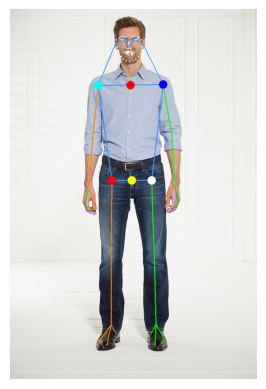

In [6]:
shoulder_midpoint = (k[6] + k[5])/2
hip_midpoint = (k[12] + k[11])/2
cv2.circle(vis, tuple(map(int, shoulder_midpoint)), 12, (255,0,0), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, hip_midpoint)), 12, (255,255,0), -1, cv2.LINE_AA)
plt.imshow(vis)
plt.axis('off')
plt.show()

In [7]:
print(shoulder_midpoint, hip_midpoint)

[357.72040653 226.09352803] [361.63194489 509.02813625]


In [9]:
torso_height = abs(shoulder_midpoint[1] - hip_midpoint[1])
torso_height

np.float64(282.9346082210541)

In [10]:
shoulder_width = abs(k[5][0] - k[6][0])
shoulder_width

np.float64(192.9692258834839)

In [11]:
ratio = shoulder_width/torso_height
ratio

np.float64(0.6820276497695853)

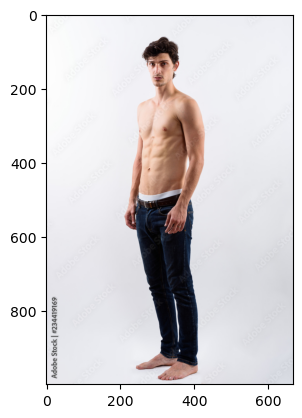

In [12]:
image_path = "/home/topiary-pc/Projects/MovesMethod/test2.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

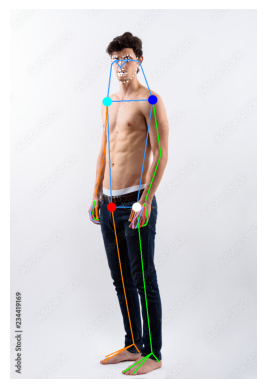

In [13]:
dets = model.det_model(img)
box = max(dets, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))
keypoints, scores = model.pose_model(img, bboxes=[box])
k, s = keypoints[0], scores[0]
vis = draw_skeleton(img.copy(), keypoints, scores, kpt_thr=0.3)
cv2.circle(vis, tuple(map(int, k[5])), 12, (0,0,255), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, k[6])), 12, (0,255,255), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, k[11])), 12, (255,255,255), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, k[12])), 12, (255,0,0), -1, cv2.LINE_AA)

plt.imshow(vis)
plt.axis('off')
plt.show()

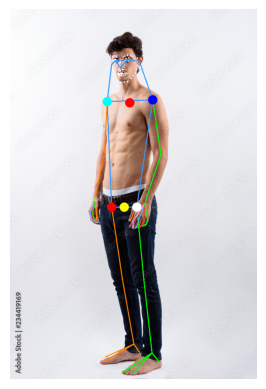

In [14]:
shoulder_midpoint = k[6] + abs(k[6] - k[5])/2
hip_midpoint = k[12] + abs(k[12] - k[11])/2
cv2.circle(vis, tuple(map(int, shoulder_midpoint)), 12, (255,0,0), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, hip_midpoint)), 12, (255,255,0), -1, cv2.LINE_AA)
plt.imshow(vis)
plt.axis('off')
plt.show()

In [15]:
torso_height = abs(shoulder_midpoint[1] - hip_midpoint[1])
shoulder_width = abs(k[5][0] - k[6][0])
ratio = shoulder_width/torso_height
ratio

np.float64(0.4358974215619319)

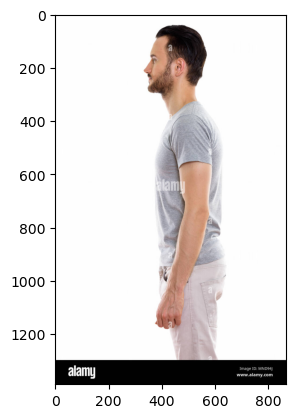

In [16]:
image_path = "/home/topiary-pc/Projects/MovesMethod/test3.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

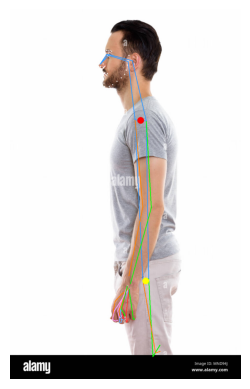

In [17]:
dets = model.det_model(img)
box = max(dets, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))
keypoints, scores = model.pose_model(img, bboxes=[box])
k, s = keypoints[0], scores[0]
vis = draw_skeleton(img.copy(), keypoints, scores, kpt_thr=0.3)
shoulder_midpoint = (k[6] + k[5])/2
hip_midpoint = k[12] + abs(k[12] - k[11])/2
cv2.circle(vis, tuple(map(int, shoulder_midpoint)), 12, (255,0,0), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, hip_midpoint)), 12, (255,255,0), -1, cv2.LINE_AA)
plt.imshow(vis)
plt.axis('off')
plt.show()

In [18]:
torso_height = abs(shoulder_midpoint[1] - hip_midpoint[1])
shoulder_width = abs(k[5][0] - k[6][0])
ratio = shoulder_width/torso_height
ratio

np.float64(0.06970509383378017)

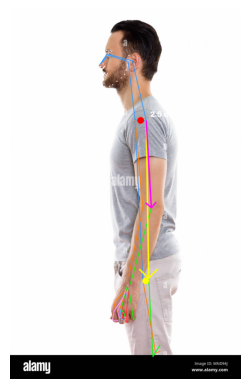

side 5/7/11  shoulder flexion = 2.5 deg


In [19]:
# shoulder flexion on the camera-facing side (test3.jpg, k/s/vis from the cell above)
sh, el, hp = (5, 7, 11) if s[7] > s[8] else (6, 8, 12)   # pick the side the model sees better

v_hip   = k[hp] - k[sh]   # shoulder -> hip
v_elbow = k[el] - k[sh]   # shoulder -> elbow
cos = np.dot(v_hip, v_elbow) / (np.linalg.norm(v_hip) * np.linalg.norm(v_elbow))
shoulder_flex = np.degrees(np.arccos(np.clip(cos, -1, 1)))

out = vis.copy()
cv2.arrowedLine(out, tuple(map(int, k[sh])), tuple(map(int, k[hp])), (255,255,0), 4, cv2.LINE_AA, tipLength=0.08)
cv2.arrowedLine(out, tuple(map(int, k[sh])), tuple(map(int, k[el])), (255,0,255), 4, cv2.LINE_AA, tipLength=0.08)
cv2.putText(out, f"{shoulder_flex:.1f} deg", tuple(map(int, k[sh] + [15, -15])), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 3, cv2.LINE_AA)
plt.imshow(out); plt.axis('off'); plt.show()
print(f"side {sh}/{el}/{hp}  shoulder flexion = {shoulder_flex:.1f} deg")
